In [ ]:
import numpy as np
import pandas as pd
import math
import random
from dataclasses import dataclass
from typing import List, Optional
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving flights_1.csv to flights_1.csv


In [ ]:

NUM_AIRCRAFT = 24
SIMULATION_STEPS = 90
TIME_STEP = 1  # 1 time step = 1 minute

AIRPORT_X, AIRPORT_Y = 0, 0

SAFE_HORIZONTAL_DISTANCE = 3  # Minimum safe horizontal separation distance (km)
SAFE_VERTICAL_DISTANCE = 300  # Minimum safe vertical separation distance

LANDING_RADIUS = 2          # Distance from airport considered as successful landing
ASSIGN_RADIUS = 20       # Distance at which aircraft become eligible for landing-slot assignment
LANDING_SEPARATION = 3

HOLDING_RADIUS = 20
HOLDING_ALTITUDES = [1500, 1800, 2100, 2400]

RUNWAYS = {
    "RWY1": {"angle_deg": 0, "next_free": 0},
    "RWY2": {"angle_deg": 90, "next_free": 0},
}
random.seed(42)
np.random.seed(42)

In [ ]:
@dataclass
class Aircraft:
    aircraft_id: int
    x: float
    y: float
    altitude: int
    speed: float
    heading: float
    fuel: float
    emergency: bool = False

    assigned_runway: Optional[str] = None
    holding_altitude: Optional[int] = None
    landing_slot: Optional[float] = None
    status: str = "incoming"   # incoming, assigned, holding, landing, landed
    wait_time: float = 0.0
    holding_time: float = 0.0
    current_conflicts: int = 0
    total_conflicts: int = 0
    priority: float = 0.0

    def distance_to_airport(self):# return Euclidean distance
        return math.hypot(self.x, self.y)

    def eta(self):
        return self.distance_to_airport() / max(self.speed, 0.1)

#normalize all parmeters in order to And the weights in priority be fair.
def normalize(value, min_val, max_val, invert=False):
    if max_val == min_val:
        score = 0.0
    else:
        score = (value - min_val) / (max_val - min_val)
    score = max(0.0, min(1.0, score))
    return 1.0 - score if invert else score


def velocity_to_heading(vx, vy):
    return math.degrees(math.atan2(vy, vx)) % 360


def load_aircraft_from_csv(file_path):
    df = pd.read_csv(file_path)

    aircraft = []
    for i, row in df.iterrows():
        horizontal_speed_mps = math.hypot(row["vx_mps"], row["vy_mps"])
        speed_km_per_step = horizontal_speed_mps / 1000.0 * TIME_STEP

        aircraft.append(
            Aircraft(
                aircraft_id=i,
                x=float(row["x_m"]) / 1000.0,
                y=float(row["y_m"]) / 1000.0,
                altitude=int(row["z_m"]),
                speed=max(speed_km_per_step, 0.5),
                heading=velocity_to_heading(row["vx_mps"], row["vy_mps"]),
                fuel=random.uniform(20, 100),
                emergency=False
            )
        )

    return aircraft

#calculates the priority of a particular aircraft a, relative to all other active aircraft.
def compute_priority(a, all_aircraft):
    active = [x for x in all_aircraft if x.status != "landed"]
    distances = [x.distance_to_airport() for x in active]
    etas = [x.eta() for x in active]
    fuels = [x.fuel for x in active]
    alts = [x.altitude for x in active]

    d = normalize(a.distance_to_airport(), min(distances), max(distances), invert=True)
    e = normalize(a.eta(), min(etas), max(etas), invert=True)
    f = normalize(a.fuel, min(fuels), max(fuels), invert=True)
    alt = normalize(a.altitude, min(alts), max(alts), invert=True)

    emergency = 1.0 if a.emergency else 0.0

    # Gives a bonus to an aircraft that has been in holding for a long time.
    holding_bonus = min(a.holding_time / 20.0, 1.0)

    a.priority = (
        0.30 * d +
        0.25 * e +
        0.20 * f +
        0.10 * alt +
        0.10 * emergency +
        0.05 * holding_bonus
    )
    return a.priority

#Find which pairs of aircrafts are close to each other
def detect_conflicts(aircraft):
    conflicts = []
    active = [a for a in aircraft if a.status != "landed"]

    for a in active:
        a.current_conflicts = 0

    for i in range(len(active)):
        for j in range(i + 1, len(active)):
            a = active[i]
            b = active[j]

            h = math.hypot(a.x - b.x, a.y - b.y)
            v = abs(a.altitude - b.altitude)

            if h < SAFE_HORIZONTAL_DISTANCE and v < SAFE_VERTICAL_DISTANCE:
                conflicts.append((a, b))
                a.current_conflicts += 1
                b.current_conflicts += 1

    return conflicts


def send_to_holding(a):
    if a.status != "holding":
        a.status = "holding"
        a.landing_slot = None
        a.assigned_runway = None
        a.holding_altitude = HOLDING_ALTITUDES[a.aircraft_id % len(HOLDING_ALTITUDES)]
        a.altitude = a.holding_altitude


def resolve_conflicts(aircraft, conflicts):
    for a, b in conflicts:
        compute_priority(a, aircraft)
        compute_priority(b, aircraft)

        if a.status == "landing" and b.status != "landing":
            loser = b
        elif b.status == "landing" and a.status != "landing":
            loser = a
        else:
            loser = a if a.priority < b.priority else b

        if loser.status in ["incoming", "assigned"]:
            send_to_holding(loser)
            loser.total_conflicts += 1


def assign_slots(aircraft, t):
    MAX_FUTURE_WINDOW = 15

    candidates = [
        a for a in aircraft
        if a.status in ["incoming", "holding"]
        and a.landing_slot is None
        and a.distance_to_airport() <= ASSIGN_RADIUS
    ]

    for a in candidates:
        compute_priority(a, aircraft)

    candidates.sort(key=lambda x: x.priority, reverse=True)

    for a in candidates:
        best_runway = None
        best_time = None

        for r in RUNWAYS:
            slot = max(t, RUNWAYS[r]["next_free"])

            #if the slot too far
            if slot - t > MAX_FUTURE_WINDOW:
                continue

            if best_time is None or slot < best_time:
                best_time = slot
                best_runway = r

        if best_runway is None:
            continue

        a.assigned_runway = best_runway
        a.landing_slot = best_time
        a.status = "assigned"
        a.holding_time = 0.0
#Update that the route will only be available after a certain time interval
#to avoid landing two aircrafts at the same time
        RUNWAYS[best_runway]["next_free"] = best_time + LANDING_SEPARATION

# moves an aircraft towards the center(0,0)
def move_toward_airport(a):
    dx = -a.x
    dy = -a.y
    d = math.hypot(dx, dy)

    if d > 0:
        step = min(a.speed * TIME_STEP, d)
        a.x += dx / d * step
        a.y += dy / d * step
        a.heading = math.degrees(math.atan2(dy, dx)) % 360


# function that moves an aircraft in a circular path around the field
def move_holding(a, t):
    radius = HOLDING_RADIUS + (a.aircraft_id % 4) * 4
    theta = 0.12 * t + a.aircraft_id
    a.x = radius * math.cos(theta)
    a.y = radius * math.sin(theta)
    a.heading = (math.degrees(theta) + 90) % 360



def update(aircraft, t):
    for a in aircraft:
        if a.status == "landed":
            continue

        if a.status in ["incoming", "assigned", "landing"]:
            move_toward_airport(a)

        elif a.status == "holding":
            move_holding(a, t)
            a.holding_time += TIME_STEP

            if a.holding_time >= 8:
                a.status = "incoming"
                a.landing_slot = None
                a.assigned_runway = None

        if a.status == "assigned" and a.landing_slot is not None and t >= a.landing_slot:
            a.status = "landing"

        if a.status == "landing" and a.distance_to_airport() <= LANDING_RADIUS:
          a.status = "landed"
          a.x, a.y = 0, 0

        if a.status in ["holding", "assigned"]:
            a.wait_time += TIME_STEP

Landed: 24
Still airborne: 0
Average wait: 11.12
Max wait: 27.0
 detected conflict : 6


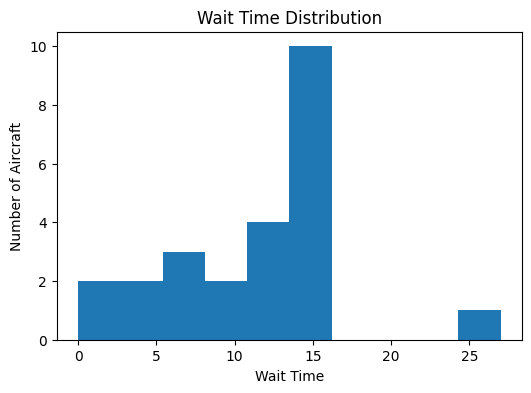

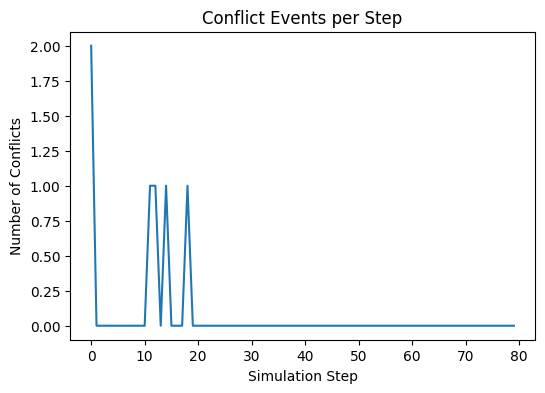

In [ ]:

df = pd.read_csv("flights_1.csv")
df = df.iloc[:24]

aircraft = []

for i, row in df.iterrows():
    vx = row["vx_mps"]
    vy = row["vy_mps"]

    speed = math.hypot(vx, vy) / 1000.0 * TIME_STEP
    heading = math.degrees(math.atan2(vy, vx)) % 360

    aircraft.append(
        Aircraft(
            aircraft_id=len(aircraft),
            x=row["x_m"] / 1000.0,
            y=row["y_m"] / 1000.0,
            altitude=int(row["z_m"]),
            speed=max(speed, 0.5),
            heading=heading,
            fuel=random.uniform(20, 100),
            emergency=False
        )
    )

NUM_AIRCRAFT = len(aircraft)

conflict_events_per_step = []
frames = [] #status of all aircrafts at time t

for t in range(SIMULATION_STEPS):
    conflicts = detect_conflicts(aircraft)
    conflict_events_per_step.append(len(conflicts))

    if conflicts:
        resolve_conflicts(aircraft, conflicts)

    assign_slots(aircraft, t) #Assigning routes
    update(aircraft, t)

    frame_data = []
    for a in aircraft:
        frame_data.append({
            "id": a.aircraft_id,
            "x": a.x,
            "y": a.y,
            "altitude": a.altitude,
            "status": a.status,
            "priority": a.priority,
            "runway": a.assigned_runway,
            "heading": a.heading
        })
    frames.append(frame_data)
landed = sum(a.status == "landed" for a in aircraft)
airborne = sum(a.status != "landed" for a in aircraft)
avg_wait = np.mean([a.wait_time for a in aircraft]) if aircraft else 0
max_wait = np.max([a.wait_time for a in aircraft]) if aircraft else 0
total_conflicts = sum(a.total_conflicts for a in aircraft)

print("Landed:", landed)
print("Still airborne:", airborne)
print("Average wait:", round(avg_wait, 2))
print("Max wait:", round(max_wait, 2))
print(" detected conflict :", total_conflicts)

plt.figure(figsize=(6, 4))
plt.hist([a.wait_time for a in aircraft], bins=10)
plt.title("Wait Time Distribution")
plt.xlabel("Wait Time")
plt.ylabel("Number of Aircraft")
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(conflict_events_per_step)
plt.title("Conflict Events per Step")
plt.xlabel("Simulation Step")
plt.ylabel("Number of Conflicts")
plt.show()

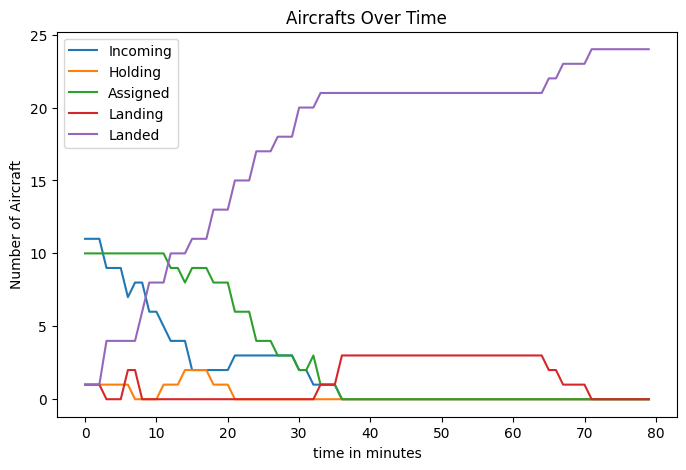

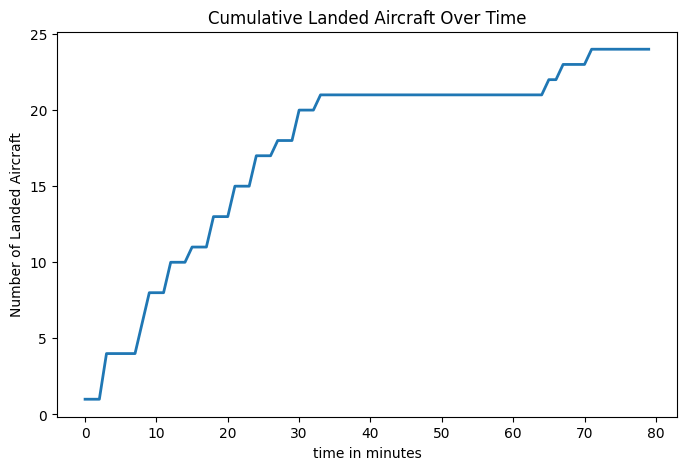

In [ ]:
#Number of Aircraft per State Over Time
states_over_time = {
    "incoming": [],
    "holding": [],
    "assigned": [],
    "landing": [],
    "landed": []
}

for frame_data in frames:
    counts = {
        "incoming": 0,
        "holding": 0,
        "assigned": 0,
        "landing": 0,
        "landed": 0
    }

    for row in frame_data:
        status = row["status"]
        if status in counts:
            counts[status] += 1

    for state in states_over_time:
        states_over_time[state].append(counts[state])

plt.figure(figsize=(8, 5))
for state, values in states_over_time.items():
    plt.plot(values, label=state.capitalize())

plt.title("Aircrafts Over Time")
plt.xlabel("time in minutes")
plt.ylabel("Number of Aircraft")
plt.legend()
plt.show()


# Cumulative Landings Over Time
cumulative_landed = []

for frame_data in frames:
    landed_count = sum(1 for row in frame_data if row["status"] == "landed")
    cumulative_landed.append(landed_count)

plt.figure(figsize=(8, 5))
plt.plot(cumulative_landed, linewidth=2)
plt.title("Cumulative Landed Aircraft Over Time")
plt.xlabel("time in minutes")
plt.ylabel("Number of Landed Aircraft")
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(9, 9))

RUNWAY_COLORS = {
    "RWY1": "deepskyblue",
    "RWY2": "violet",
    None: "white"
}

STATUS_MARKERS = {
    "incoming": "^",
    "holding": "s",
    "assigned": "D",
    "landing": "v",
    "landed": "o"
}

STATUS_DEFAULT_COLORS = {
    "incoming": "deepskyblue",
    "holding": "orange",
    "assigned": "violet",
    "landing": "lime",
    "landed": "red"
}


def draw_airport():
    ax.clear()
    ax.set_facecolor("#08111f")
    fig.patch.set_facecolor("#08111f")

    # distance rings
    for r in [20, 40, 60, 80, 100]:
        circle = plt.Circle((0, 0), r, color="#2b6e4f", fill=False, alpha=0.35, linewidth=1.4)
        ax.add_patch(circle)

    # runways
    ax.plot([-8, 8], [0, 0], color="lightgray", linewidth=5, solid_capstyle="round")
    ax.plot([0, 0], [-8, 8], color="gray", linewidth=4, alpha=0.85, solid_capstyle="round")

    # airport center
    ax.scatter([0], [0], s=180, c="gold", marker="*", label="Airport")

    ax.set_xlim(-130, 130)
    ax.set_ylim(-130, 130)
    ax.set_title("Safe Skies Simulation", color="white", fontsize=17)
    ax.tick_params(colors="white")
    for spine in ax.spines.values():
        spine.set_color("white")
        spine.set_alpha(0.3)


def get_plane_color(row):
    # landing / assigned לפי runway
    if row["status"] in ["assigned", "landing"]:
        return RUNWAY_COLORS.get(row["runway"], "white")
    return STATUS_DEFAULT_COLORS.get(row["status"], "white")


def draw_heading_arrow(x, y, heading, color):
    arrow_len = 5
    dx = arrow_len * math.cos(math.radians(heading))
    dy = arrow_len * math.sin(math.radians(heading))
    ax.arrow(
        x, y, dx, dy,
        head_width=1.8,
        head_length=2.4,
        fc=color,
        ec=color,
        alpha=0.8,
        length_includes_head=True
    )


def update_animation(frame_idx):
    draw_airport()
    data = frames[frame_idx]

    for row in data:
        color = get_plane_color(row)
        marker = STATUS_MARKERS.get(row["status"], "o")

        ax.scatter(
            row["x"],
            row["y"],
            s=90 if row["status"] != "landed" else 110,
            marker=marker,
            color=color,
            edgecolors="white",
            linewidths=0.6,
            zorder=3
        )


        if row["status"] != "landed":
            draw_heading_arrow(row["x"], row["y"], row["heading"], color)

        ax.text(
            row["x"] + 2.0,
            row["y"] + 2.0,
            f"A{row['id']} | P={row['priority']:.2f}",
            color="white",
            fontsize=7.5,
            zorder=4
        )


    legend_handles = [
        plt.Line2D([0], [0], marker='^', color='w', label='Incoming', markerfacecolor='deepskyblue', markersize=9, linestyle=''),
        plt.Line2D([0], [0], marker='s', color='w', label='Holding', markerfacecolor='orange', markersize=9, linestyle=''),
        plt.Line2D([0], [0], marker='D', color='w', label='Assigned (by runway)', markerfacecolor='violet', markersize=9, linestyle=''),
        plt.Line2D([0], [0], marker='v', color='w', label='Landing (by runway)', markerfacecolor='lime', markersize=9, linestyle=''),
        plt.Line2D([0], [0], marker='o', color='w', label='Landed', markerfacecolor='red', markersize=9, linestyle=''),
        plt.Line2D([0], [0], marker='*', color='w', label='Airport', markerfacecolor='gold', markersize=12, linestyle='')
    ]

    leg = ax.legend(handles=legend_handles, loc="upper right", facecolor="#101a2b", edgecolor="white", fontsize=9)
    for text in leg.get_texts():
        text.set_color("white")

    landed_now = sum(1 for row in data if row["status"] == "landed")
    holding_now = sum(1 for row in data if row["status"] == "holding")

    ax.text(
        -126, 122,
        f"Step: {frame_idx}",
        color="white",
        fontsize=10,
        fontweight="bold"
    )

    ax.text(
        -126, 114,
        f"Conflicts: {conflict_events_per_step[frame_idx]}",
        color="white",
        fontsize=10
    )

    ax.text(
        -126, 106,
        f"Landed so far: {landed_now}/{NUM_AIRCRAFT}",
        color="white",
        fontsize=10
    )

    ax.text(
        -126, 98,
        f"Holding now: {holding_now}",
        color="white",
        fontsize=10
    )


ani = FuncAnimation(
    fig,
    update_animation,
    frames=len(frames),
    interval=350,
    repeat=False
)

plt.close(fig)
display(HTML(ani.to_jshtml()))

In [ ]:
# ============================================================
# Comparison Framework: Baselines + Safe Skies
# ============================================================

def load_aircraft(file_path="flights_1.csv"):
    df = pd.read_csv(file_path).iloc[:NUM_AIRCRAFT]
    aircraft = []

    for _, row in df.iterrows():
        vx = row["vx_mps"]
        vy = row["vy_mps"]

        speed = math.hypot(vx, vy) / 1000.0 * TIME_STEP
        heading = math.degrees(math.atan2(vy, vx)) % 360

        aircraft.append(
            Aircraft(
                aircraft_id=len(aircraft),
                x=float(row["x_m"]) / 1000.0,
                y=float(row["y_m"]) / 1000.0,
                altitude=int(row["z_m"]),
                speed=max(speed, 0.5),
                heading=heading,
                fuel=20 + (len(aircraft) * 7 % 80),  # deterministic fuel
                emergency=False
            )
        )

    return aircraft


def reset_runways():
    return {
        "RWY1": {"angle_deg": 0, "next_free": 0},
        "RWY2": {"angle_deg": 90, "next_free": 0},
    }


def resolve_conflicts_baseline(aircraft, conflicts):
    for a, b in conflicts:

        # Simple rule: aircraft with later ETA is sent to holding
        loser = b if a.eta() <= b.eta() else a

        if loser.status in ["incoming", "assigned"]:
            send_to_holding(loser)
            loser.total_conflicts += 1


def estimate_conflict_risk(a, aircraft):
    risk = 0

    for b in aircraft:
        if a.aircraft_id == b.aircraft_id or b.status == "landed":
            continue

        horizontal_dist = math.hypot(a.x - b.x, a.y - b.y)
        vertical_dist = abs(a.altitude - b.altitude)

        if (
            horizontal_dist < SAFE_HORIZONTAL_DISTANCE * 1.5
            and vertical_dist < SAFE_VERTICAL_DISTANCE * 1.5
        ):
            risk += 1

    return risk


# FIFO Baseline

def assign_slots_fifo(aircraft, t, runways):
    candidates = [
        a for a in aircraft
        if a.status in ["incoming", "holding"]
        and a.landing_slot is None
        and a.distance_to_airport() <= ASSIGN_RADIUS
    ]

    candidates.sort(key=lambda a: a.aircraft_id)

    for a in candidates:
        best_runway = min(runways, key=lambda r: max(t, runways[r]["next_free"]))
        best_time = max(t, runways[best_runway]["next_free"])

        a.assigned_runway = best_runway
        a.landing_slot = best_time
        a.status = "assigned"

        runways[best_runway]["next_free"] = best_time + LANDING_SEPARATION

# ETA

def assign_slots_eta(aircraft, t, runways):
    candidates = [
        a for a in aircraft
        if a.status in ["incoming", "holding"]
        and a.landing_slot is None
        and a.distance_to_airport() <= ASSIGN_RADIUS
    ]

    candidates.sort(key=lambda a: a.eta())

    for a in candidates:
        best_runway = min(runways, key=lambda r: max(t, runways[r]["next_free"]))
        best_time = max(t, runways[best_runway]["next_free"])

        a.assigned_runway = best_runway
        a.landing_slot = best_time
        a.status = "assigned"

        runways[best_runway]["next_free"] = best_time + LANDING_SEPARATION

# Conflict-Aware ETA (ETA + conflict-risk penalty)

def assign_slots_conflict_aware_eta(aircraft, t, runways):
    candidates = [
        a for a in aircraft
        if a.status in ["incoming", "holding"]
        and a.landing_slot is None
        and a.distance_to_airport() <= ASSIGN_RADIUS
    ]

    candidates.sort(
        key=lambda a: a.eta() + 5.0 * estimate_conflict_risk(a, aircraft)
    )

    for a in candidates:
        best_runway = min(runways, key=lambda r: max(t, runways[r]["next_free"]))
        best_time = max(t, runways[best_runway]["next_free"])

        a.assigned_runway = best_runway
        a.landing_slot = best_time
        a.status = "assigned"

        runways[best_runway]["next_free"] = best_time + LANDING_SEPARATION



# Trajectory-Aware Baseline (ETA + distance + conflict risk)

def assign_slots_trajectory_aware(aircraft, t, runways):
    candidates = [
        a for a in aircraft
        if a.status in ["incoming", "holding"]
        and a.landing_slot is None
        and a.distance_to_airport() <= ASSIGN_RADIUS
    ]

    candidates.sort(
        key=lambda a: (
            0.6 * a.eta()
            + 0.3 * a.distance_to_airport()
            + 4.0 * estimate_conflict_risk(a, aircraft)
        )
    )

    for a in candidates:
        best_runway = min(runways, key=lambda r: max(t, runways[r]["next_free"]))
        best_time = max(t, runways[best_runway]["next_free"])

        a.assigned_runway = best_runway
        a.landing_slot = best_time
        a.status = "assigned"

        runways[best_runway]["next_free"] = best_time + LANDING_SEPARATION


# Optimization-Inspired Heuristic Baseline

def assign_slots_optimization_heuristic(aircraft, t, runways):
    candidates = [
        a for a in aircraft
        if a.status in ["incoming", "holding"]
        and a.landing_slot is None
        and a.distance_to_airport() <= ASSIGN_RADIUS
    ]

    if not candidates:
        return

    max_eta = max(a.eta() for a in candidates) or 1
    max_dist = max(a.distance_to_airport() for a in candidates) or 1
    max_risk = max(estimate_conflict_risk(a, aircraft) for a in candidates) or 1

    def heuristic_score(a):
        eta_score = 1 - (a.eta() / max_eta)
        dist_score = 1 - (a.distance_to_airport() / max_dist)
        risk_score = estimate_conflict_risk(a, aircraft) / max_risk
        holding_score = min(a.holding_time / 20.0, 1.0)

        return (
            0.35 * eta_score
            + 0.30 * dist_score
            + 0.20 * risk_score
            + 0.15 * holding_score
        )

    candidates.sort(key=heuristic_score, reverse=True)

    for a in candidates:
        best_runway = min(runways, key=lambda r: max(t, runways[r]["next_free"]))
        best_time = max(t, runways[best_runway]["next_free"])

        a.assigned_runway = best_runway
        a.landing_slot = best_time
        a.status = "assigned"

        runways[best_runway]["next_free"] = best_time + LANDING_SEPARATION

#Safe Skies
def assign_slots_safe_skies_custom(aircraft, t, runways):
    MAX_FUTURE_WINDOW = 15

    candidates = [
        a for a in aircraft
        if a.status in ["incoming", "holding"]
        and a.landing_slot is None
        and a.distance_to_airport() <= ASSIGN_RADIUS
    ]

    for a in candidates:
        compute_priority(a, aircraft)

    candidates.sort(key=lambda a: a.priority, reverse=True)

    for a in candidates:
        best_runway = None
        best_time = None

        for r in runways:
            slot = max(t, runways[r]["next_free"])

            if slot - t > MAX_FUTURE_WINDOW:
                continue

            if best_time is None or slot < best_time:
                best_time = slot
                best_runway = r

        if best_runway is None:
            continue

        a.assigned_runway = best_runway
        a.landing_slot = best_time
        a.status = "assigned"
        a.holding_time = 0.0

        runways[best_runway]["next_free"] = best_time + LANDING_SEPARATION



def run_simulation(strategy_name, assign_function, conflict_resolution_function):
    aircraft = load_aircraft("flights_1.csv")
    runways = reset_runways()

    conflict_events_per_step = []
    avg_wait_over_time = []

    for t in range(SIMULATION_STEPS):
        conflicts = detect_conflicts(aircraft)
        conflict_events_per_step.append(len(conflicts))

        if conflicts:
            conflict_resolution_function(aircraft, conflicts)

        assign_function(aircraft, t, runways)
        update(aircraft, t)

        avg_wait_over_time.append(np.mean([a.wait_time for a in aircraft]))

    landed = sum(a.status == "landed" for a in aircraft)
    airborne = sum(a.status != "landed" for a in aircraft)

    avg_wait = np.mean([a.wait_time for a in aircraft])
    max_wait = np.max([a.wait_time for a in aircraft])

    detected_conflicts = sum(conflict_events_per_step)
    holding_resolutions = sum(a.total_conflicts for a in aircraft)

    return {
        "Strategy": strategy_name,
        "Landed": landed,
        "Airborne": airborne,
        "Average Wait (min)": round(avg_wait, 2),
        "Maximum Wait (min)": round(max_wait, 2),
        "Detected Conflicts": detected_conflicts,
        "Holding Resolutions": holding_resolutions,
        "Avg Wait Over Time": avg_wait_over_time
    }

In [ ]:
results = []

results.append(run_simulation( "FIFO", assign_slots_fifo, resolve_conflicts_baseline))

results.append(run_simulation("ETA-Based",  assign_slots_eta, resolve_conflicts_baseline))

results.append(run_simulation( "Conflict-Aware ETA",assign_slots_conflict_aware_eta,resolve_conflicts_baseline))

results.append(run_simulation("Trajectory-Aware",assign_slots_trajectory_aware, resolve_conflicts_baseline))

results.append(run_simulation(
    "Optimization Heuristic",
    assign_slots_optimization_heuristic,
    resolve_conflicts_baseline
))

results.append(run_simulation(
    "Safe Skies",
    assign_slots_safe_skies_custom,
    resolve_conflicts
))

comparison_df = pd.DataFrame(results)
comparison_df


,Strategy,Landed,Airborne,Average Wait (min),Maximum Wait (min),Detected Conflicts,Holding Resolutions,Avg Wait Over Time
0,FIFO,18,6,34.00,80.0,378,282,"[0.9166666666666666, 1.8333333333333333, 2.75,..."
1,ETA-Based,22,2,22.42,80.0,137,104,"[0.9166666666666666, 1.8333333333333333, 2.75,..."
2,Conflict-Aware ETA,22,2,22.54,80.0,149,109,"[0.9166666666666666, 1.8333333333333333, 2.75,..."
3,Trajectory-Aware,22,2,22.54,80.0,149,109,"[0.9166666666666666, 1.8333333333333333, 2.75,..."
4,Optimization Heuristic,23,1,20.83,80.0,33,33,"[0.9166666666666666, 1.8333333333333333, 2.75,..."
5,Safe Skies,24,0,11.21,23.0,5,5,"[0.4583333333333333, 0.9166666666666666, 1.375..."


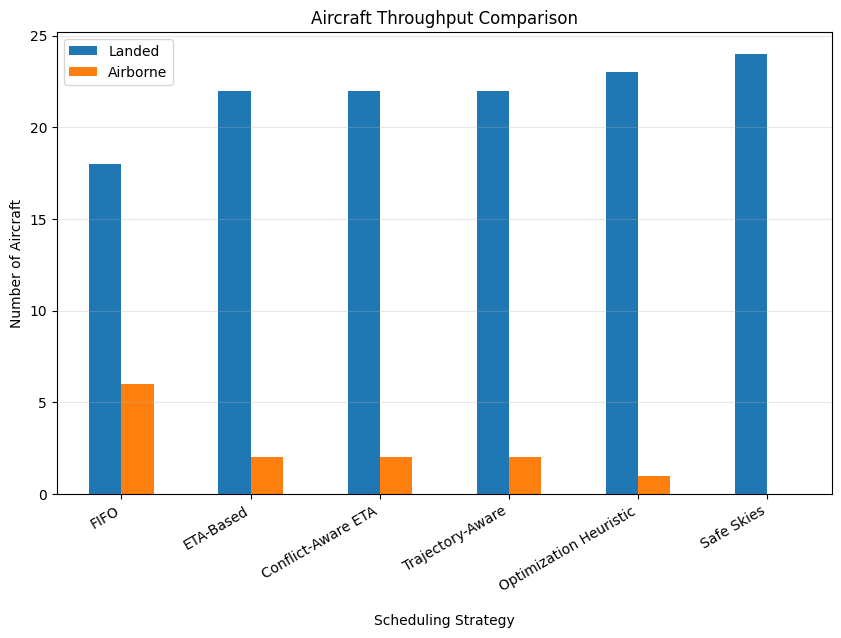

In [ ]:
comparison_df.plot( x="Strategy", y=["Landed", "Airborne"], kind="bar", figsize=(10, 6))
plt.title("Aircraft Throughput Comparison")
plt.xlabel("Scheduling Strategy", labelpad=15)
plt.ylabel("Number of Aircraft")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.show()

In [ ]:

for _, row in comparison_df.iterrows():

    strategy = row["Strategy"]
    avg_wait = row["Average Wait (min)"]
    print(f"{strategy}")
    print(f"    Average Wait: {avg_wait:.2f} minutes")


FIFO
    Average Wait: 34.00 minutes
ETA-Based
    Average Wait: 22.42 minutes
Conflict-Aware ETA
    Average Wait: 22.54 minutes
Trajectory-Aware
    Average Wait: 22.54 minutes
Optimization Heuristic
    Average Wait: 20.83 minutes
Safe Skies
    Average Wait: 11.21 minutes


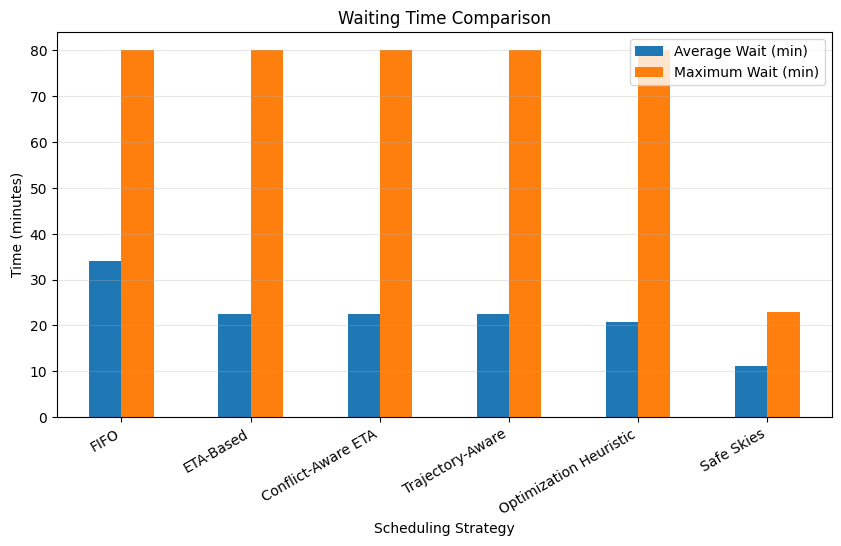

In [ ]:
comparison_df.plot(
    x="Strategy",
    y=["Average Wait (min)", "Maximum Wait (min)"],
    kind="bar",
    figsize=(10, 5)
)

plt.title("Waiting Time Comparison")
plt.xlabel("Scheduling Strategy")
plt.ylabel("Time (minutes)")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.show()

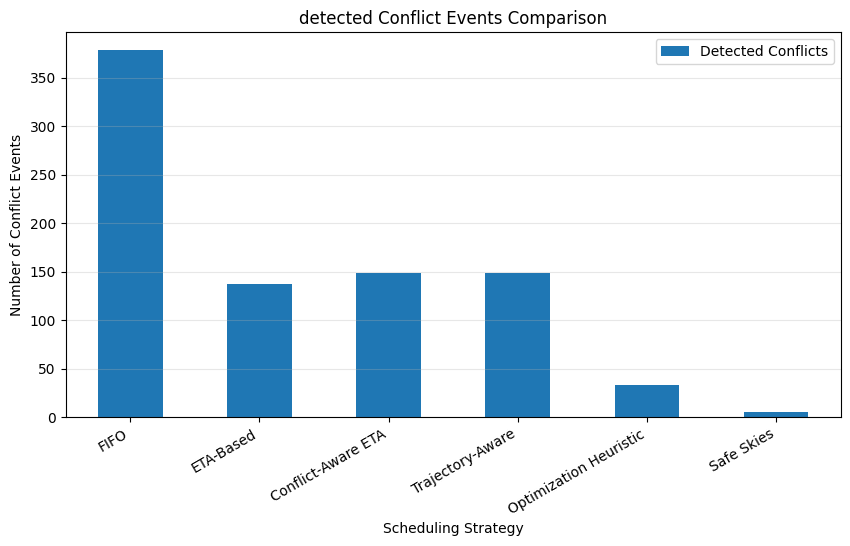

In [ ]:
comparison_df.plot(
    x="Strategy",
    y=["Detected Conflicts"],
    kind="bar",
    figsize=(10, 5)
)

plt.title("detected Conflict Events Comparison")
plt.xlabel("Scheduling Strategy")
plt.ylabel("Number of Conflict Events")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.show()

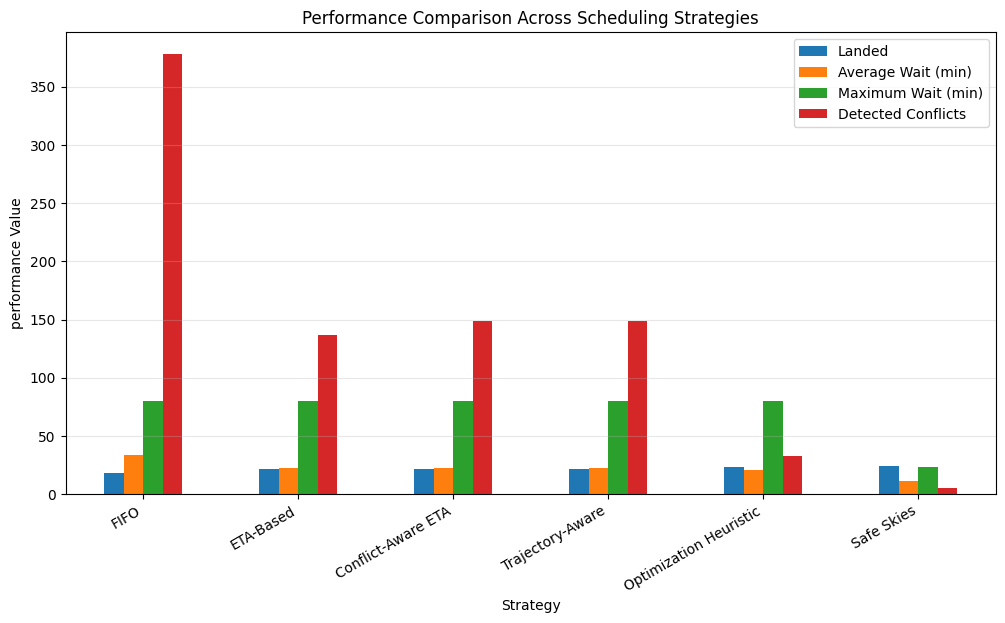

In [ ]:
comparison_df.plot(
    x="Strategy",
    y=["Landed", "Average Wait (min)", "Maximum Wait (min)", "Detected Conflicts"],
    kind="bar",
    figsize=(12, 6)
)

plt.title("Performance Comparison Across Scheduling Strategies")
plt.ylabel("performance Value")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.show()

In [ ]:
safe_wait = comparison_df.loc[
    comparison_df["Strategy"] == "Safe Skies",
    "Average Wait (min)"
].values[0]

relative_wait_difference = comparison_df[
    comparison_df["Strategy"] != "Safe Skies"
].copy()

relative_wait_difference["Relative Difference"] = abs(
    (relative_wait_difference["Average Wait (min)"] - safe_wait)
    / relative_wait_difference["Average Wait (min)"]
)

relative_wait_difference[
    ["Strategy", "Average Wait (min)", "Relative Difference"]
]

,Strategy,Average Wait (min),Relative Difference
0,FIFO,34.00,0.670294
1,ETA-Based,22.42,0.500000
2,Conflict-Aware ETA,22.54,0.502662
3,Trajectory-Aware,22.54,0.502662
4,Optimization Heuristic,20.83,0.461834


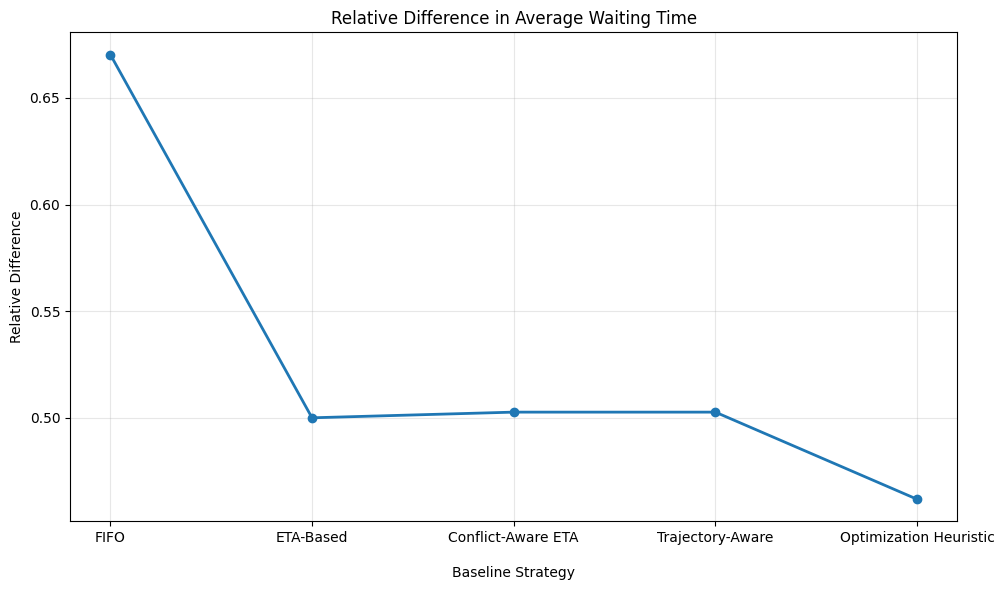

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(
    relative_wait_difference["Strategy"],
    relative_wait_difference["Relative Difference"],
    marker='o',
    linewidth=2
)

plt.title("Relative Difference in Average Waiting Time")
plt.xlabel("Baseline Strategy", labelpad=15)
plt.tight_layout()
plt.ylabel("Relative Difference")
plt.grid(True, alpha=0.3)
plt.show()

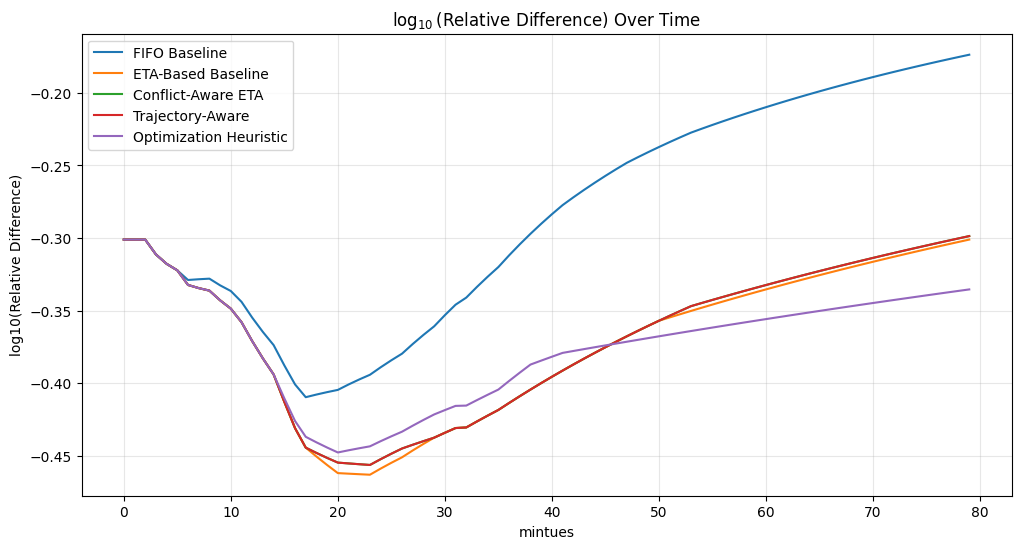

In [ ]:
safe_data = None

for r in results:
    if r["Strategy"] == "Safe Skies":
        safe_data = r["Avg Wait Over Time"]

plt.figure(figsize=(12, 6))

for r in results:

    if r["Strategy"] == "Safe Skies":
        continue

    baseline = np.array(r["Avg Wait Over Time"])
    safe = np.array(safe_data)
    eps = 1e-6

    relative_difference = np.abs((baseline - safe) / (baseline + eps))

    log_relative_difference = np.log10(relative_difference + eps)

    plt.plot( log_relative_difference,label=r["Strategy"])

plt.title(r"$\log_{10}(\mathrm{Relative\ Difference})$ Over Time")
plt.xlabel("mintues")
plt.ylabel("log10(Relative Difference)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:

# Test performance under increasing number of aircraft

aircraft_counts = [15,20, 24, 26,40]

scalability_results = []

for n in aircraft_counts:
    NUM_AIRCRAFT = n

    strategies = [
        ("FIFO Baseline", assign_slots_fifo, resolve_conflicts_baseline),
        ("ETA-Based Baseline", assign_slots_eta, resolve_conflicts_baseline),
        ("Conflict-Aware ETA", assign_slots_conflict_aware_eta, resolve_conflicts_baseline),
        ("Trajectory-Aware", assign_slots_trajectory_aware, resolve_conflicts_baseline),
        ("Optimization Heuristic", assign_slots_optimization_heuristic, resolve_conflicts_baseline),
        ("Safe Skies", assign_slots_safe_skies_custom, resolve_conflicts),
    ]

    for strategy_name, assign_func, conflict_func in strategies:
        result = run_simulation(strategy_name, assign_func, conflict_func)
        result["Aircraft Count"] = n
        scalability_results.append(result)

scalability_df = pd.DataFrame(scalability_results)

scalability_df

,Strategy,Landed,Airborne,Average Wait (min),Maximum Wait (min),Detected Conflicts,Holding Resolutions,Avg Wait Over Time,Aircraft Count
0,FIFO Baseline,15,0,15.40,60.0,29,27,"[0.8666666666666667, 1.7333333333333334, 2.6, ...",15
1,ETA-Based Baseline,15,0,9.80,21.0,1,1,"[0.8666666666666667, 1.7333333333333334, 2.6, ...",15
2,Conflict-Aware ETA,15,0,9.80,21.0,1,1,"[0.8666666666666667, 1.7333333333333334, 2.6, ...",15
3,Trajectory-Aware,15,0,9.80,21.0,1,1,"[0.8666666666666667, 1.7333333333333334, 2.6, ...",15
4,Optimization Heuristic,15,0,9.80,21.0,1,1,"[0.8666666666666667, 1.7333333333333334, 2.6, ...",15
5,Safe Skies,15,0,9.00,15.0,1,1,"[0.6666666666666666, 1.3333333333333333, 2.0, ...",15
6,FIFO Baseline,18,2,26.70,90.0,101,97,"[0.9, 1.8, 2.7, 3.5, 4.3, 5.1, 5.85, 6.6, 7.35...",20
7,ETA-Based Baseline,20,0,14.10,30.0,3,3,"[0.9, 1.8, 2.7, 3.5, 4.3, 5.1, 5.8, 6.5, 7.2, ...",20
8,Conflict-Aware ETA,20,0,14.25,30.0,3,3,"[0.9, 1.8, 2.7, 3.5, 4.3, 5.1, 5.8, 6.5, 7.2, ...",20
9,Trajectory-Aware,20,0,14.25,30.0,3,3,"[0.9, 1.8, 2.7, 3.5, 4.3, 5.1, 5.8, 6.5, 7.2, ...",20


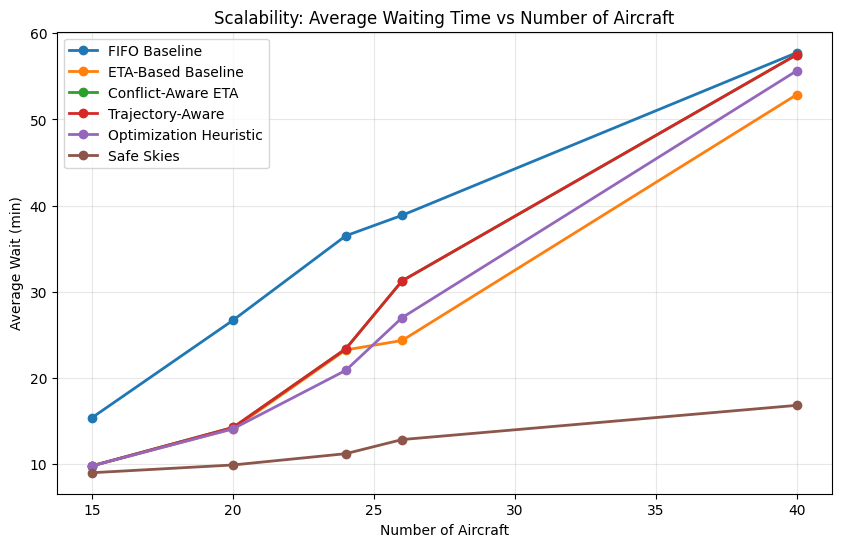

In [ ]:
plt.figure(figsize=(10, 6))

for strategy in scalability_df["Strategy"].unique():
    data = scalability_df[scalability_df["Strategy"] == strategy]
    plt.plot(
        data["Aircraft Count"],
        data["Average Wait (min)"],
        marker="o",
        linewidth=2,
        label=strategy
    )

plt.title("Scalability: Average Waiting Time vs Number of Aircraft")
plt.xlabel("Number of Aircraft")
plt.ylabel("Average Wait (min)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

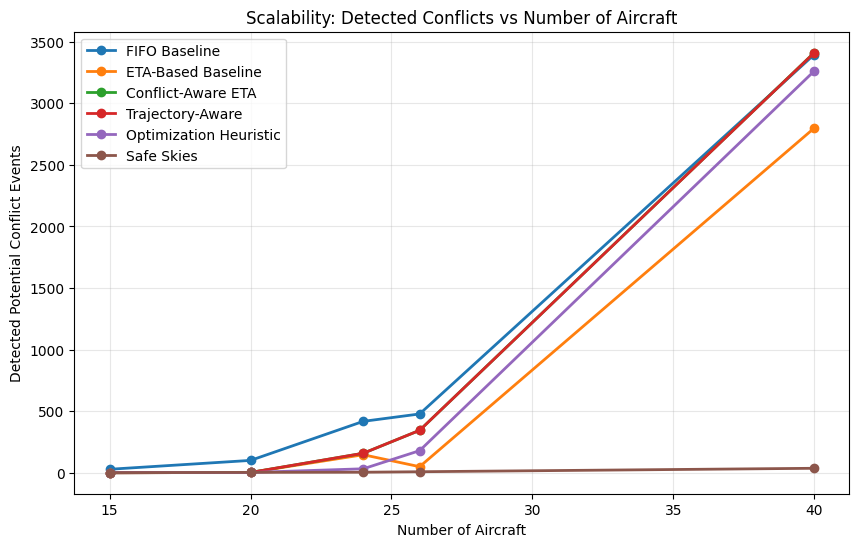

In [ ]:
plt.figure(figsize=(10, 6))

for strategy in scalability_df["Strategy"].unique():
    data = scalability_df[scalability_df["Strategy"] == strategy]
    plt.plot(
        data["Aircraft Count"],
        data["Detected Conflicts"],
        marker="o",
        linewidth=2,
        label=strategy
    )

plt.title("Scalability: Detected Conflicts vs Number of Aircraft")
plt.xlabel("Number of Aircraft")
plt.ylabel("Detected Potential Conflict Events")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

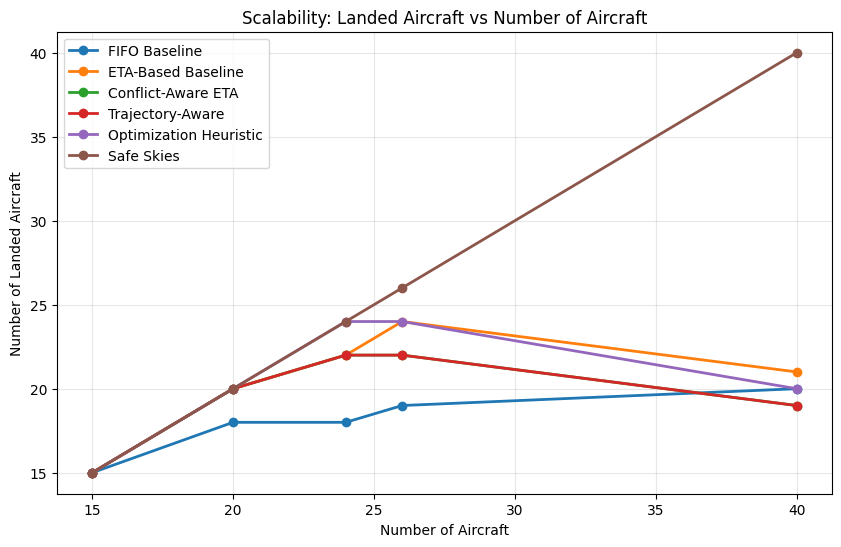

In [ ]:
plt.figure(figsize=(10, 6))

for strategy in scalability_df["Strategy"].unique():
    data = scalability_df[scalability_df["Strategy"] == strategy]
    plt.plot(
        data["Aircraft Count"],
        data["Landed"],
        marker="o",
        linewidth=2,
        label=strategy
    )

plt.title("Scalability: Landed Aircraft vs Number of Aircraft")
plt.xlabel("Number of Aircraft")
plt.ylabel("Number of Landed Aircraft")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [ ]:
summary_40 = scalability_df[scalability_df["Aircraft Count"] == 40][[
    "Strategy",
    "Landed",
    "Airborne",
    "Average Wait (min)",
    "Maximum Wait (min)",
    "Detected Conflicts",
    "Holding Resolutions"
]]

summary_40 = summary_40.rename(columns={
    "Landed": "Landed Aircraft",
    "Airborne": "Airborne Aircraft",
    "Average Wait": "Average Wait (min)",
    "Maximum Wait": "Maximum Wait (min)"
})

summary_40 = summary_40.sort_values(
    by=["Landed Aircraft", "Average Wait (min)"],
    ascending=[False, True]
)

summary_40.reset_index(drop=True, inplace=True)



In [ ]:
display(
    summary_40.style
    .background_gradient(cmap="Greens", subset=["Landed Aircraft"])
    .background_gradient(cmap="Reds", subset=["Average Wait (min)", "Detected Conflicts"])
)

,Strategy,Landed Aircraft,Airborne Aircraft,Average Wait (min),Maximum Wait (min),Detected Conflicts,Holding Resolutions
0,Safe Skies,40,0,16.820000,30.000000,37,26
1,ETA-Based Baseline,21,19,52.880000,90.000000,2798,1179
2,Optimization Heuristic,20,20,55.650000,90.000000,3261,1263
3,FIFO Baseline,20,20,57.750000,90.000000,3395,1292
4,Conflict-Aware ETA,19,21,57.520000,90.000000,3410,1346
5,Trajectory-Aware,19,21,57.520000,90.000000,3409,1346
